# Weighting adjustments: when the weights depend on the data

[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb)
treated survey weights as fixed, public numbers — a fact about the sampling
design, known in advance. Real survey weights are rarely left at that.
Agencies routinely adjust the design weights twice more: once for unit
*nonresponse* (inflating the weight of respondents to stand in for
similar people who didn't respond) and once for *calibration* (rescaling
weights so weighted totals match known benchmarks, e.g. from a census).

Drechsler & Bailie's Section 5 makes a simple but important point: both
adjustments are *data dependent* — they're computed from the very responses
they're then used to weight — so "changing one record can potentially
change the weight-adjustment factors for all other units." A sensitivity
bound that only accounts for one record's own value, as
[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb)
did, misses this entirely.

This notebook demonstrates the effect with the simplest common calibration
technique — post-stratification — where the mechanism is completely
transparent, and then shows a regularization strategy (in the spirit of
Clifton et al. (2023) and the same weight-capping idea from
[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb))
that bounds it back down.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import opendp.prelude as dp

dp.enable_features("contrib", "honest-but-curious")

from noisyvalue import opendp as nvdp

## Post-stratification: a simple, transparent calibration

Split the population into `H` post-strata (say, age group x region cells),
each with a *known* population size `N_h` from an external benchmark like
the census. Within stratum `h`, if `n_h` sample respondents fall into it,
the post-stratified weight given to each of them is

```
w_i = w0 * N_h / n_h        (i in stratum h)
```

— exactly what's needed so the weighted count for stratum `h` sums to the
known `N_h`. `w0 = N/n` is the ordinary design weight. Every respondent in
a stratum shares the *same* weight, and that weight is a function of `n_h`,
the count of who else responded within that stratum.

In [2]:
rng = np.random.default_rng(0)

N, n, R = 2000, 200, 1.0
w0 = N / n
H = 10

N_h = rng.integers(150, 300, size=H)
N_h = (N_h / N_h.sum() * N).round().astype(int)
N_h[-1] += N - N_h.sum()   # exact benchmark population sizes per stratum

strata = rng.choice(H, size=n, p=N_h / N_h.sum())
y = np.clip(0.5 + rng.normal(0, 0.25, n), 0.0, 1.0)


def poststrat_weights(strata_assignment, floor=1):
    # floor: a regularization knob introduced below -- ignore it for now (floor=1 is a no-op)
    n_h = np.maximum(np.bincount(strata_assignment, minlength=H), floor)
    return w0 * N_h[strata_assignment] / n_h[strata_assignment]


w = poststrat_weights(strata)
total = (w * y).sum()
print(f"stratum sample counts: {np.bincount(strata, minlength=H)}")
print(f"post-stratified total: {total:.1f}, max weight: {w.max():.1f} "
      f"(design weight alone would be {w0:.1f})")

stratum sample counts: [24 20 18 20 15 20 12 14 20 37]
post-stratified total: 9758.2, max weight: 130.8 (design weight alone would be 10.0)


## Changing one record moves everyone else's weight

Take one respondent in a stratum and change their record enough that they
now fall into a *different* stratum (e.g. their age or region was recorded
differently) — a bounded, one-record change of exactly the kind DP's
neighboring-dataset definition allows. Because `n_h` drops by one, the
weight for *every other respondent left in that stratum* jumps — not just
the moved respondent's own contribution.

In [3]:
def ripple_on_others(h, floor=1):
    members = np.where(strata == h)[0]
    if len(members) < 2:
        return 0.0
    moved = members[0]
    perturbed = strata.copy()
    perturbed[moved] = (h + 1) % H   # one record's data now places them elsewhere

    w_before = poststrat_weights(strata, floor)
    w_after = poststrat_weights(perturbed, floor)
    others = members[members != moved]
    return ((w_after[others] - w_before[others]) * y[others]).sum()


naive_bound = w0 * R   # the sensitivity horvitz_thompson_sensitivity.ipynb would have assumed
print(f"{'stratum':>8} {'n_h':>5} {'ripple on others':>18} {'x naive bound':>14}")
for h in range(H):
    n_h = (strata == h).sum()
    ripple = ripple_on_others(h)
    print(f"{h:>8} {n_h:>5} {ripple:>18.2f} {ripple / naive_bound:>13.1f}x")

 stratum   n_h   ripple on others  x naive bound
       0    24              59.62           6.0x
       1    20              55.82           5.6x
       2    18              58.55           5.9x
       3    20              41.74           4.2x
       4    15              72.09           7.2x
       5    20              34.30           3.4x
       6    12              64.47           6.4x
       7    14              53.93           5.4x
       8    20              45.60           4.6x
       9    37              29.69           3.0x


Every stratum shows a ripple several times the size of the single-record
bound that
[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb)
would have used — and this is only from *one* neighboring respondent moving
between strata; a genuinely adversarial worst case (e.g. targeting the
smallest stratum, or several respondents at once) can push it further
still. This is precisely the paper's warning: naively applying DP to a
poststratified estimate, using only the design-weight sensitivity, silently
under-protects every other respondent sharing a small cell with the changed
record.

## Regularizing the adjustment: floor the cell size

The fix mirrors
[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb)'s
weight cap, applied to the *adjustment* instead of the design weight: floor
`n_h` at some minimum before dividing, so a stratum's weight can never be
driven up by an unusually small respondent count. Once the floor is at
least as large as every realized `n_h`, the weight stops depending on the
sample composition at all — the ripple vanishes completely, at the cost of
a poststratified total that's biased away from the true design-based
estimate (small strata get systematically under-weighted).

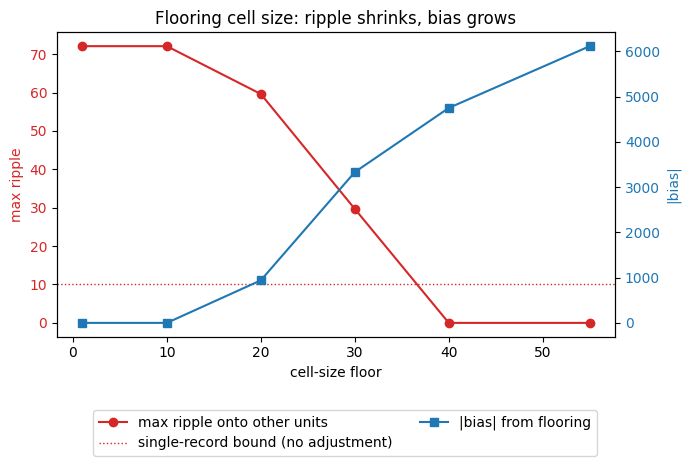

In [4]:
floors = [1, 10, 20, 30, 40, 55]
records = []
for floor in floors:
    max_ripple = max(abs(ripple_on_others(h, floor)) for h in range(H))
    w_floored = poststrat_weights(strata, floor)
    bias = (w_floored * y).sum() - total
    records.append((floor, max_ripple, abs(bias)))

floors_arr, ripple_arr, bias_arr = map(np.array, zip(*records))

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(floors_arr, ripple_arr, "o-", color="tab:red", label="max ripple onto other units")
ax1.axhline(naive_bound, color="tab:red", linestyle=":", linewidth=1,
            label="single-record bound (no adjustment)")
ax1.set_xlabel("cell-size floor")
ax1.set_ylabel("max ripple", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

ax2 = ax1.twinx()
ax2.plot(floors_arr, bias_arr, "s-", color="tab:blue", label="|bias| from flooring")
ax2.set_ylabel("|bias|", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

ax1.set_title("Flooring cell size: ripple shrinks, bias grows")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
plt.tight_layout()

As with weight capping, there's no floor that's free: a small one leaves
the adjustment almost as data-dependent as before, and a large one flattens
the weights back toward the plain design weight, discarding exactly the
correction post-stratification exists to make. Once the floor exceeds every
realized `n_h`, the ripple is provably zero (the weights no longer read the
sample's composition at all) — at that point the statistic is *fixed*-weight
again, and the sensitivity story collapses back to
[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb)'s.
Picking a floor that's tight enough to preserve most of the calibration's
accuracy while still bounding the sensitivity to something workable is
exactly the "robust adjustment strategy" question the paper flags as open —
Clifton et al. (2023) is the Census Bureau's own preliminary attempt at it,
for post-stratification specifically.

## Releasing the regularized estimator

With a chosen floor, the poststratified total finally has a bound
sensitivity we can hand to `nvdp.make_gaussian`, exactly as in
[`horvitz_thompson_sensitivity.ipynb`](horvitz_thompson_sensitivity.ipynb):
the worst case is a stratum whose sample count is pinned at the floor, so
`sensitivity = w0 * N_h.max() / floor * R`.

In [5]:
floor = 25
w_floored = poststrat_weights(strata, floor)
sensitivity = w0 * N_h.max() / floor * R

trans = dp.t.make_sum(
    dp.vector_domain(dp.atom_domain(bounds=(0.0, sensitivity), nan=False)),
    dp.symmetric_distance())
scale = sensitivity / 1.0   # eps = 1
meas = trans >> nvdp.make_gaussian(trans.output_domain, trans.output_metric, scale)

value = meas((w_floored * y).tolist())
print(f"floor={floor}: sensitivity={sensitivity:.1f}, released total={value}")
print(f"(true design-based total: {total:.1f}; unfloored sensitivity would have "
      f"been {w0 * N_h[np.argmin(np.bincount(strata, minlength=H))] / 1:.1f}, "
      f"and even that ignores the ripple onto other units)")

floor=25: sensitivity=108.0, released total=~7516.605341111916
(true design-based total: 9758.2; unfloored sensitivity would have been 1570.0, and even that ignores the ripple onto other units)


## What we didn't solve

Flooring bounds *this* particular data-dependence — the cell counts — but
it's a partial fix, not a general one: a more elaborate calibration or
nonresponse-propensity model (e.g. a logistic regression fit to the whole
sample, as agencies commonly use for nonresponse) doesn't decompose into
per-cell counts this cleanly, and capping its *output* weights bounds each
respondent's own contribution without bounding how much a model refit can
move everyone else's. The genuinely clean fix in that case is the same one
[`imputation_and_dp.ipynb`](imputation_and_dp.ipynb) uses for the
structurally identical problem in imputation: estimate the model's
parameters *once*, via a dedicated DP mechanism, and hold them fixed rather
than re-fitting them from each release's own respondent pattern.